In [1]:
from langchain_core.prompts import ChatPromptTemplate

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

## **Pydantic LLM Schema**

In [3]:
from pydantic import BaseModel, Field
from typing import List
class llm_schema(BaseModel):
    task:List[str] = Field(description="This is the list of task that you as an agent must perform")

model_with_schema = model.with_structured_output(llm_schema)

In [4]:
dummy_task = "What is the capital of france & what is the population of france ?"

model_with_schema.invoke(dummy_task)

llm_schema(task=['What is the capital of France?', 'What is the population of France?'])

## **Graph schema**

In [5]:
class graph_schema(BaseModel):
    tasks: List[str]
    query: str
    results: List[str]
    summary: str

## **Orchestrator Node**

In [6]:
def orchestrator(state: graph_schema)-> graph_schema:
    user_query = state.query

    prompt = ChatPromptTemplate(
        [
            ("system","You are an orchestrator that breaks the user query into smaller tasks for the workers"),
            ("user",f"{user_query}. Please generate a prompt per task for the worker to perform")
        ]
    )

    chain = prompt | model_with_schema

    response = chain.invoke({"query":user_query})

    state.tasks = response.task

    return state

## **Worker Node**

In [7]:
def execute(query:str):
    
    response = model.invoke(query)

    return response

In [8]:
from concurrent.futures import ThreadPoolExecutor

def worker_node(state:graph_schema) -> graph_schema:

    tasks = state.tasks

    results = []

    with ThreadPoolExecutor(max_workers=len(tasks)) as executor:
        result_futures = executor.map(execute, tasks)

        for result in result_futures:
            results.append(result)

        state.resutls = results

        return state

## **Collector Node**

In [9]:
def collector_node(state:graph_schema) -> graph_schema:
    results = state.resutls
    prompt = ChatPromptTemplate(
        [
            ("system","You are a collector that summarizes different results obtained from different workers"),
            ("user",f"Here are the results: {results}, please summarize these results in a concise pattern")
        ]
    )

    chain = prompt | model
    
    summary = chain.invoke({"results":results})

    state.summary = summary

    return state

In [10]:
from langgraph.graph import StateGraph, START,END

orchestrator_worker_graph = StateGraph(graph_schema)

orchestrator_worker_graph.add_node("orchestrator",orchestrator)
orchestrator_worker_graph.add_node("worker",worker_node)
orchestrator_worker_graph.add_node("collector",collector_node)




In [11]:
orchestrator_worker_graph.add_edge(START,"orchestrator")
orchestrator_worker_graph.add_edge("orchestrator","worker")
orchestrator_worker_graph.add_edge("worker","collector")
orchestrator_worker_graph.add_edge("collector",END)

In [12]:
orchestrator_worker_graph_compiled = orchestrator_worker_graph.compile()

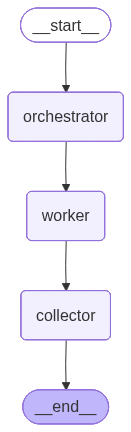

In [13]:
from IPython.display import Image,display

Image(orchestrator_worker_graph_compiled.get_graph().draw_mermaid_png())

In [14]:
orchestrator_worker_graph_compiled.invoke({
    "query":"what is the capital of France & What is the population of Germany ?",
    "tasks":[],
    "results":[],
    "summary":""
})

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 5.616113844s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerMo